In [2]:
#Librerias requeridas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Carga de datos
df = pd.read_spss('../data/raw/201512_EnemduBDD_con.SAV')

# Ver los primeros datos
df.head()

,area,ciudad,zona,sector,panelm,vivienda,hogar,c01,c02,c03,...,c07,c08,c09,c10,c11,c12,c13,id_sector,plan_muestreo,fexp
0,Urbana,10150.0,001,003,Panel A2,Vivienda Uno,Hogar Uno,Igual,Igual,Menor,...,Igual,Igual,No,No,No,Peor,Peor,1.015000e+10,1013,64.249774
1,Urbana,10150.0,001,003,Panel A2,Vivienda Dos,Hogar Uno,Peor,Peor,Menor,...,Igual,Igual,No,No,No,Peor,Peor,1.015000e+10,1013,64.249774
2,Urbana,10150.0,001,003,Panel A2,Vivienda Tres,Hogar Uno,Peor,Peor,Menor,...,Menor,Menor,No,No,No,Peor,Peor,1.015000e+10,1013,64.249774
3,Urbana,10150.0,001,003,Panel B2,Vivienda Uno,Hogar Uno,Igual,Igual,Menor,...,Menor,Menor,No,No,No,Peor,Peor,1.015000e+10,1013,64.249774
4,Urbana,10150.0,001,003,Panel B2,Vivienda Dos,Hogar Uno,Igual,Igual,Menor,...,Menor,Menor,No,No,No,Peor,Peor,1.015000e+10,1013,64.249774


In [3]:
#Carga de datos
df = pd.read_spss('../data/raw/201512_EnemduBDD_15anios.sav')

# Ver los primeros datos
df.head()

,area,ciudad,zona,sector,panelm,vivienda,hogar,p01,p02,p03,...,nc,desem,desemab,desemoc,desem1,desem2,pein,id_sector,plan_muestreo,fexp
0,1.0,10150.0,009,004,Panel B2,Vivienda Uno,Hogar Uno,Persona 3,Hombre,26.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.015001e+10,1012,141.065750
1,1.0,10150.0,056,005,Panel A2,Vivienda Tres,Hogar Uno,Persona 1,Hombre,68.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Población Económicamente Inactiva,1.015006e+10,1012,65.976281
2,1.0,70150.0,005,001,Panel B2,Vivienda Dos,Hogar Dos,Persona 1,Hombre,41.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.015001e+10,1072,123.512430
3,1.0,70150.0,043,004,Panel B2,Vivienda Uno,Hogar Uno,Persona 1,Hombre,38.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.015004e+10,1071,96.697327
4,1.0,80150.0,012,003,Panel A2,Vivienda Uno,Hogar Uno,Persona 1,Hombre,64.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.015001e+10,1081,89.319663


In [4]:
import os
import pandas as pd

folder_path = '../data/raw/'
all_dfs = []

# 1. Listar solo archivos que sean de "Personas" o bases completas
# Evitamos los que terminan en '_con.sav' (que suelen ser de Hogares)
archivos = [f for f in os.listdir(folder_path) if f.endswith('.sav') and 'persona' in f.lower() or '15anios' in f.lower()]

for archivo in archivos:
    print(f"--- Procesando: {archivo} ---")
    
    try:
        # Cargar archivo
        temp_df = pd.read_spss(os.path.join(folder_path, archivo))
        
        # Estandarizar nombres a minúsculas para evitar errores de 'AREA' vs 'area'
        temp_df.columns = temp_df.columns.str.lower()
        
        # Definir las columnas que queremos (en minúsculas)
        columnas_deseadas = ['area', 'p02', 'p03', 'fexp']
        
        # 2. Verificar cuáles de estas columnas existen realmente en este archivo
        columnas_presentes = [col for col in columnas_deseadas if col in temp_df.columns]
        
        if len(columnas_presentes) < len(columnas_deseadas):
            print(f"⚠️ Alerta: Faltan columnas en {archivo}. Solo se encontraron: {columnas_presentes}")
        
        # Extraer solo lo que existe y añadir el año
        # Si el nombre empieza con el año (ej. 2015...), lo extraemos
        anio = "".join(filter(str.isdigit, archivo))[:4] 
        subset = temp_df[columnas_presentes].copy()
        subset['anio_fiscal'] = anio
        
        all_dfs.append(subset)
        
    except Exception as e:
        print(f"❌ Error crítico en {archivo}: {e}")

# Unir todo
if all_dfs:
    df_historico = pd.concat(all_dfs, ignore_index=True)
    print("\n✅ ¡Consolidación completada con éxito!")
    print(df_historico.head())
else:
    print("❌ No se pudo consolidar ningún archivo.")

--- Procesando: 201512_EnemduBDD_15anios.sav ---
--- Procesando: BDDenemdu_personas_2018_anual.sav ---
--- Procesando: BDDenemdu_personas_2019_anual.sav ---
--- Procesando: BDDenemdu_personas_2021_anual.sav ---
--- Procesando: enemdu_persona_2022_12.sav ---
--- Procesando: enemdu_persona_2023_12.sav ---

✅ ¡Consolidación completada con éxito!
  area     p02   p03        fexp anio_fiscal
0  1.0  Hombre  26.0  141.065750        2015
1  1.0  Hombre  68.0   65.976281        2015
2  1.0  Hombre  41.0  123.512430        2015
3  1.0  Hombre  38.0   96.697327        2015
4  1.0  Hombre  64.0   89.319663        2015


In [5]:
# Guardar en formato Pickle (mantiene categorías y tipos de datos de pandas)
df_historico.to_pickle('../data/processed/enemdu_historica_2015_2023.pkl')

print("✅ ¡Logrado! Base guardada en formato Pickle.")

✅ ¡Logrado! Base guardada en formato Pickle.


In [6]:
# Ver cuántos datos tenemos por año y por área
print("Distribución por año y área:")
print(pd.crosstab(df_historico['anio_fiscal'], df_historico['area']))

# Ver qué etiquetas tiene la columna de sexo
print("\nEtiquetas en la variable p02 (Sexo):")
print(df_historico['p02'].value_counts())

Distribución por año y área:
area           1.0    2.0   Rural   Urbana   Rural  Urbana
anio_fiscal                                               
2015         66646  46175       0        0       0       0
2018             0      0       0        0  134872  347676
2019             0      0       0        0  136673  347852
2021             0      0       0        0   97487  264303
2022             0      0    7722    21271       0       0
2023             0      0    7693    20613       0       0

Etiquetas en la variable p02 (Sexo):
p02
Mujer      736472
Hombre     705212
 Mujer      29664
 Hombre     27635
Name: count, dtype: int64


In [7]:
# 1. Eliminar espacios en blanco invisibles al inicio o final de los textos
df_historico['area'] = df_historico['area'].astype(str).str.strip()
df_historico['p02'] = df_historico['p02'].astype(str).str.strip()

# 2. Mapear los códigos numéricos a etiquetas (Basado en metodología INEC)
# 1.0 solía ser Urbana y 2.0 Rural en las bases antiguas
mapeo_area = {
    '1.0': 'Urbana',
    '2.0': 'Rural',
    'nan': 'Sin Dato' # Manejo de nulos si existieran
}

# Aplicar el reemplazo
df_historico['area'] = df_historico['area'].replace(mapeo_area)

# 3. Unificar Sexo (p02)
# Esto corregirá los duplicados de "Mujer" y "Hombre"
mapeo_sexo = {
    '1.0': 'Hombre', # En caso de que algún año venga como número
    '2.0': 'Mujer'
}
df_historico['p02'] = df_historico['p02'].replace(mapeo_sexo)

print("✅ Estandarización completada.")

✅ Estandarización completada.


In [8]:
# Verificación final
print("Distribución unificada por Área:")
print(pd.crosstab(df_historico['anio_fiscal'], df_historico['area']))

print("\nEtiquetas unificadas de Sexo:")
print(df_historico['p02'].value_counts())

Distribución unificada por Área:
area          Rural  Urbana
anio_fiscal                
2015          46175   66646
2018         134872  347676
2019         136673  347852
2021          97487  264303
2022           7722   21271
2023           7693   20613

Etiquetas unificadas de Sexo:
p02
Mujer     766136
Hombre    732847
Name: count, dtype: int64


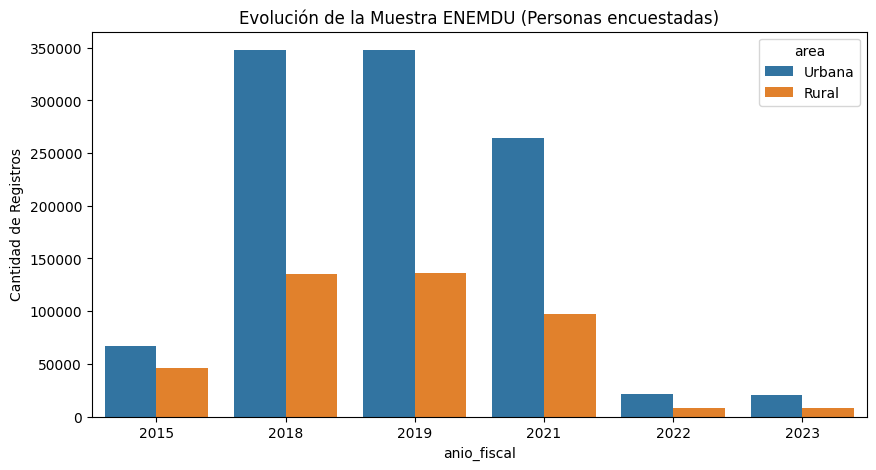

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
# Graficamos el conteo de personas por año y área
sns.countplot(data=df_historico, x='anio_fiscal', hue='area')
plt.title('Evolución de la Muestra ENEMDU (Personas encuestadas)')
plt.ylabel('Cantidad de Registros')
plt.show()

In [10]:
columnas_deseadas = ['area', 'p02', 'p03', 'fexp', 'ingpc', 'pobreza', 'epobreza']
all_dfs = []

for archivo in archivos:
    print(f"Buscando variables en: {archivo}...")
    temp_df = pd.read_spss(os.path.join(folder_path, archivo))
    temp_df.columns = temp_df.columns.str.lower()
    
    # Identificar qué columnas de la lista existen en este archivo
    presentes = [col for col in columnas_deseadas if col in temp_df.columns]
    
    anio = "".join(filter(str.isdigit, archivo))[:4]
    subset = temp_df[presentes].copy()
    subset['anio_fiscal'] = anio
    all_dfs.append(subset)

df_historico = pd.concat(all_dfs, ignore_index=True)

# Volvemos a estandarizar etiquetas (como hicimos antes)
df_historico['area'] = df_historico['area'].astype(str).str.strip().replace({'1.0': 'Urbana', '2.0': 'Rural'})
df_historico['p02'] = df_historico['p02'].astype(str).str.strip().replace({'1.0': 'Hombre', '2.0': 'Mujer'})

# Guardamos la versión completa
df_historico.to_pickle('../data/processed/enemdu_historica_completa.pkl')
print("✅ Base histórica actualizada con variables de pobreza.")

Buscando variables en: 201512_EnemduBDD_15anios.sav...
Buscando variables en: BDDenemdu_personas_2018_anual.sav...
Buscando variables en: BDDenemdu_personas_2019_anual.sav...
Buscando variables en: BDDenemdu_personas_2021_anual.sav...
Buscando variables en: enemdu_persona_2022_12.sav...
Buscando variables en: enemdu_persona_2023_12.sav...
✅ Base histórica actualizada con variables de pobreza.


In [11]:
import os
import pandas as pd

# Definimos las variables objetivo y sus posibles variantes de nombre
# ingpc: Ingreso Per Cápita, p10a: Nivel de instrucción, pobreza: Indicador ya calculado
columnas_objetivo = ['area', 'p02', 'p03', 'fexp', 'ingpc', 'p10a', 'pobreza', 'epobreza']
folder_path = '../data/raw/'
all_dfs = []

# Filtrar archivos de personas
archivos = [f for f in os.listdir(folder_path) if f.endswith('.sav') and ('persona' in f.lower() or '15anios' in f.lower())]

for archivo in archivos:
    print(f"🔄 Procesando variables en: {archivo}...")
    try:
        temp_df = pd.read_spss(os.path.join(folder_path, archivo))
        temp_df.columns = temp_df.columns.str.lower()
        
        # Identificar qué columnas de nuestra lista existen en este archivo específico
        columnas_presentes = [col for col in columnas_objetivo if col in temp_df.columns]
        
        # Extraer año
        anio = "".join(filter(str.isdigit, archivo))[:4]
        
        # Crear copia con las columnas encontradas
        subset = temp_df[columnas_presentes].copy()
        subset['anio_fiscal'] = anio
        
        all_dfs.append(subset)
        print(f"   ✅ Columnas rescatadas: {len(columnas_presentes)}")
        
    except Exception as e:
        print(f"   ❌ Error en {archivo}: {e}")

# Unir todo el historial
df_historico = pd.concat(all_dfs, ignore_index=True)

# --- ESTANDARIZACIÓN MAESTRA ---
# 1. ÁREA: Unificar etiquetas y códigos
df_historico['area'] = df_historico['area'].astype(str).str.strip().replace({'1.0': 'Urbana', '2.0': 'Rural'})

# 2. SEXO: Unificar etiquetas y códigos
df_historico['p02'] = df_historico['p02'].astype(str).str.strip().replace({'1.0': 'Hombre', '2.0': 'Mujer'})

# 3. EDUCACIÓN (p10a): Limpiar espacios
if 'p10a' in df_historico.columns:
    df_historico['p10a'] = df_historico['p10a'].astype(str).str.strip()

# Guardar la versión final en Pickle
df_historico.to_pickle('../data/processed/enemdu_historica_completa.pkl')

print("\n🚀 ¡TODO LISTO! Base histórica completa y guardada.")
print(f"Forma final del dataset: {df_historico.shape}")

🔄 Procesando variables en: 201512_EnemduBDD_15anios.sav...
   ✅ Columnas rescatadas: 8
🔄 Procesando variables en: BDDenemdu_personas_2018_anual.sav...
   ✅ Columnas rescatadas: 8
🔄 Procesando variables en: BDDenemdu_personas_2019_anual.sav...
   ✅ Columnas rescatadas: 8
🔄 Procesando variables en: BDDenemdu_personas_2021_anual.sav...
   ✅ Columnas rescatadas: 8
🔄 Procesando variables en: enemdu_persona_2022_12.sav...
   ✅ Columnas rescatadas: 8
🔄 Procesando variables en: enemdu_persona_2023_12.sav...
   ✅ Columnas rescatadas: 8

🚀 ¡TODO LISTO! Base histórica completa y guardada.
Forma final del dataset: (1498983, 9)


In [12]:
# Ver las categorías de educación (p10a)
print("Categorías de nivel de instrucción (p10a):")
print(df_historico['p10a'].value_counts().head(10))

# Ver estadísticas descriptivas del ingreso per cápita
print("\nResumen del Ingreso Per Cápita (ingpc):")
print(df_historico.groupby('anio_fiscal')['ingpc'].describe())

Categorías de nivel de instrucción (p10a):
p10a
Educación Básica             327280
Primaria                     298906
Secundaria                   294657
Superior Universitario       221388
Educación  Media             162442
Ninguno                       45644
Superior no universitario     24130
Post-grado                    20020
Centro de alfabetización       3280
Name: count, dtype: int64

Resumen del Ingreso Per Cápita (ingpc):
                count        mean         std       min         25%  \
anio_fiscal                                                           
2015         111694.0  215.554712  301.790347  0.250000   78.000000   
2018         479125.0  276.519599  365.931660  0.333333  105.000000   
2019         480984.0  276.729105  385.876808  0.333333  105.000000   
2021         357828.0  250.251599  405.132141  0.200000   90.000000   
2022          28831.0  296.543269  384.592113  0.600000  110.000000   
2023          28162.0  292.353917  319.925278  1.000000  112.857

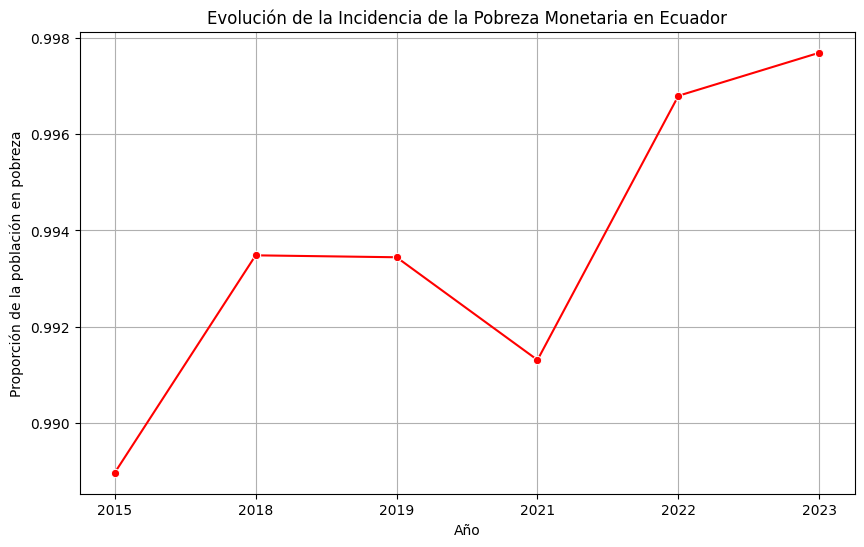

In [13]:
# Creamos una columna numérica para facilitar el cálculo si 'pobreza' es texto
df_historico['es_pobre'] = (df_historico['pobreza'].astype(str).str.contains('Pobre', case=False)).astype(int)

# Cálculo de la tasa de pobreza ponderada por año
def tasa_pobreza(group):
    return (group['es_pobre'] * group['fexp']).sum() / group['fexp'].sum()

pobreza_anual = df_historico.groupby('anio_fiscal').apply(tasa_pobreza).reset_index()
pobreza_anual.columns = ['anio_fiscal', 'tasa_pobreza']

# Visualización
plt.figure(figsize=(10, 6))
sns.lineplot(data=pobreza_anual, x='anio_fiscal', y='tasa_pobreza', marker='o', color='red')
plt.title('Evolución de la Incidencia de la Pobreza Monetaria en Ecuador')
plt.ylabel('Proporción de la población en pobreza')
plt.xlabel('Año')
plt.grid(True)
plt.show()

In [14]:
# Ver exactamente qué etiquetas hay en la columna de pobreza
print("Etiquetas encontradas en la variable pobreza:")
print(df_historico['pobreza'].value_counts())

Etiquetas encontradas en la variable pobreza:
pobreza
NO POBRE    1194931
POBRE        291693
Name: count, dtype: int64


In [15]:
# El secreto está en añadir .str antes de .strip()
df_historico['es_pobre'] = (df_historico['pobreza'].astype(str).str.strip() == 'Pobre').astype(int)
print("Etiquetas reales en la base:")
print(df_historico['pobreza'].unique())

Etiquetas reales en la base:
['NO POBRE', NaN, 'POBRE']
Categories (2, str): ['NO POBRE', 'POBRE']


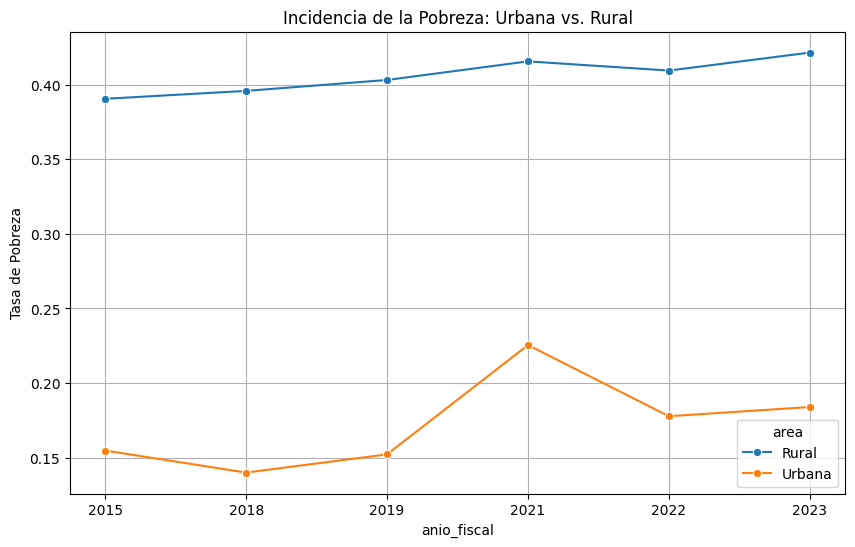

In [16]:
# 1. Definimos la función (para que Python la "conozca")
def tasa_pobreza_real(group):
    # Usamos fexp para que el cálculo sea estadísticamente representativo
    return (group['es_pobre'] * group['fexp']).sum() / group['fexp'].sum()

# 2. Corregimos la lógica para que coincida con tus etiquetas en MAYÚSCULAS
# Usamos .upper() para asegurarnos de que no importe cómo esté escrito
df_historico['es_pobre'] = (df_historico['pobreza'].astype(str).str.strip().str.upper() == 'POBRE').astype(int)

# 3. Ahora sí, calculamos la pobreza por año y área
pobreza_area = df_historico.groupby(['anio_fiscal', 'area']).apply(tasa_pobreza_real).reset_index()
pobreza_area.columns = ['anio_fiscal', 'area', 'tasa_pobreza']

# 4. Graficamos
plt.figure(figsize=(10, 6))
sns.lineplot(data=pobreza_area, x='anio_fiscal', y='tasa_pobreza', hue='area', marker='o')
plt.title('Incidencia de la Pobreza: Urbana vs. Rural')
plt.ylabel('Tasa de Pobreza')
plt.grid(True)
plt.show()

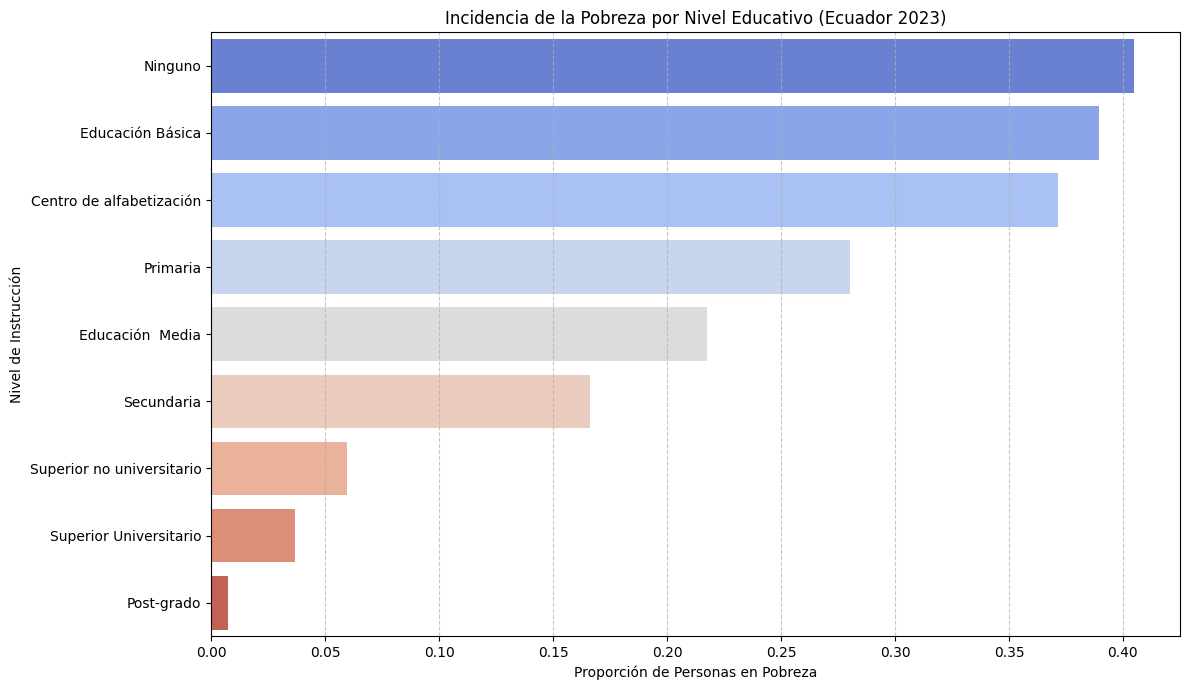

In [17]:
# 1. Filtramos para el año 2023 para tener la foto más reciente
df_2023 = df_historico[df_historico['anio_fiscal'] == '2023'].copy()

# 2. Calculamos la pobreza por nivel de instrucción
# Usamos la función tasa_pobreza_real que definimos antes
pobreza_edu = df_2023.groupby('p10a').apply(tasa_pobreza_real).reset_index()
pobreza_edu.columns = ['nivel_instruccion', 'tasa_pobreza']

# 3. Ordenamos por tasa de pobreza para que el gráfico sea más legible
pobreza_edu = pobreza_edu.sort_values('tasa_pobreza', ascending=False)

# 4. Graficamos
plt.figure(figsize=(12, 7))
sns.barplot(data=pobreza_edu, x='tasa_pobreza', y='nivel_instruccion', hue='nivel_instruccion', palette='coolwarm', legend=False)
plt.title('Incidencia de la Pobreza por Nivel Educativo (Ecuador 2023)')
plt.xlabel('Proporción de Personas en Pobreza')
plt.ylabel('Nivel de Instrucción')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

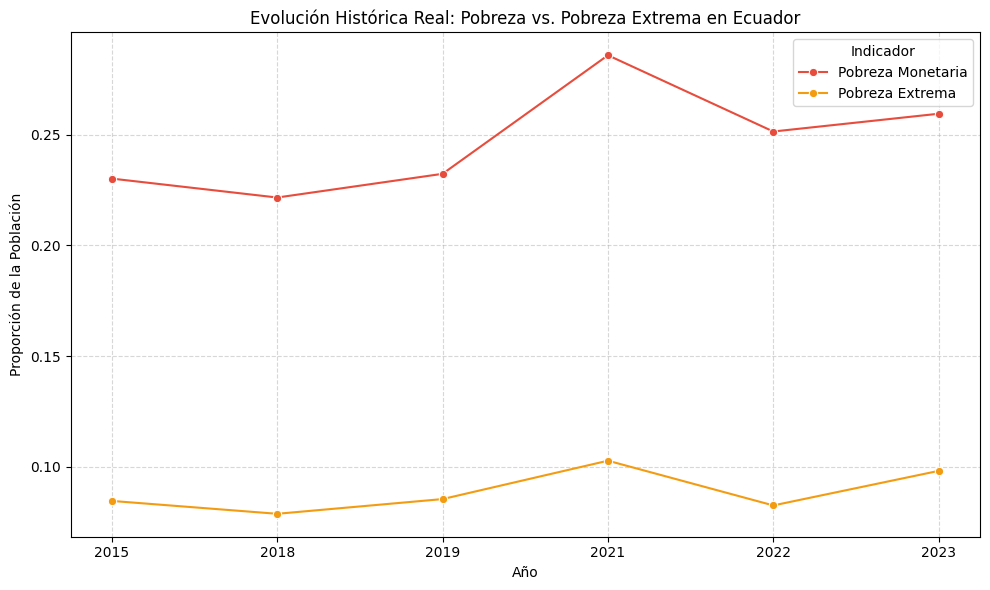

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Estandarización estricta que maneja nulos y asegura el formato numérico
def homologar_extrema(valor):
    val_str = str(valor).strip().upper()
    if val_str in ['NAN', 'NONE', '.', 'NAN.0']: 
        return np.nan
    if 'INDIGENTE' in val_str and 'NO' not in val_str:
        return 1.0
    return 0.0

# Aplicamos la función y aseguramos que el tipo de dato sea float
df_historico['es_pobre_extremo'] = df_historico['epobreza'].apply(homologar_extrema).astype(float)
df_historico['es_pobre'] = df_historico['es_pobre'].astype(float)
df_historico['fexp'] = df_historico['fexp'].astype(float)

# 2. Función matemática con vectores limpios de NumPy
def calcular_ambas_tasas_limpias(group):
    # Pobreza general
    pob_array = group['es_pobre'].to_numpy()
    fexp_array = group['fexp'].to_numpy()
    tasa_pob = np.sum(pob_array * fexp_array) / np.sum(fexp_array)
    
    # Pobreza extrema filtrando nulos
    subgrupo = group.dropna(subset=['es_pobre_extremo'])
    if not subgrupo.empty:
        ext_array = subgrupo['es_pobre_extremo'].to_numpy()
        fexp_ext_array = subgrupo['fexp'].to_numpy()
        tasa_ext = np.sum(ext_array * fexp_ext_array) / np.sum(fexp_ext_array)
    else:
        tasa_ext = np.nan
        
    return pd.Series({'Pobreza Monetaria': tasa_pob, 'Pobreza Extrema': tasa_ext})

# 3. Agrupación limpia (sin el argumento include_groups)
comparativo_pobreza = df_historico.groupby('anio_fiscal').apply(calcular_ambas_tasas_limpias).reset_index()

# 4. Transformar a formato largo para Seaborn
comparativo_long = pd.melt(comparativo_pobreza, id_vars=['anio_fiscal'], 
                           value_vars=['Pobreza Monetaria', 'Pobreza Extrema'],
                           var_name='Indicador', value_name='Tasa')

# 5. Graficar la tendencia real
plt.figure(figsize=(10, 6))
sns.lineplot(data=comparativo_long, x='anio_fiscal', y='Tasa', hue='Indicador', marker='o', palette=['#e74c3c', '#f39c12'])
plt.title('Evolución Histórica Real: Pobreza vs. Pobreza Extrema en Ecuador')
plt.ylabel('Proporción de la Población')
plt.xlabel('Año')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [19]:
import pandas as pd
import numpy as np

# 1. Funciones estadísticas ponderadas para el groupby
def calcular_tasa_pobreza(group):
    return (group['es_pobre'] * group['fexp']).sum() / group['fexp'].sum()

def calcular_tasa_extrema(group):
    subgrupo = group.dropna(subset=['es_pobre_extremo'])
    if not subgrupo.empty:
        return (subgrupo['es_pobre_extremo'] * subgrupo['fexp']).sum() / subgrupo['fexp'].sum()
    return np.nan

# ==========================================
# PUNTO 1 & 3: COMPARACIONES Y VARIACIÓN ANUAL
# ==========================================

# Calculamos las tasas anuales por Área (Urbana / Rural)
tabla_historica = df_historico.groupby(['anio_fiscal', 'area']).apply(lambda g: pd.Series({
    'Pobreza': calcular_tasa_pobreza(g),
    'Pobreza_Extrema': calcular_tasa_extrema(g)
})).reset_index()

# Pivotamos la tabla para que sea más fácil calcular las variaciones
tabla_pobreza_evolucion = tabla_historica.pivot(index='anio_fiscal', columns='area', values='Pobreza')

# Calcular la Variación Anual Absoluta (en puntos porcentuales: Año t - Año t-1)
# Multiplicamos por 100 para leerlo directamente como puntos porcentuales
var_anual_pobreza = tabla_pobreza_evolucion.diff() * 100

print("📊 1. COMPARATIVO HISTÓRICO DE LA POBREZA (Tasa de Incidencia)")
print(tabla_pobreza_evolucion.round(4) * 100)

print("\n📈 2. VARIACIÓN ANUAL EN PUNTOS PORCENTUALES (Año con año)")
print(var_anual_pobreza.round(2))

# ==========================================
# PUNTO 2: PROMEDIOS HISTÓRICOS
# ==========================================

print("\n🧮 3. PROMEDIOS HISTÓRICOS DE LA SERIE (2015-2023)")
promedio_pobreza = df_historico.groupby('area').apply(calcular_tasa_pobreza) * 100
promedio_extrema = df_historico.groupby('area').apply(calcular_tasa_extrema) * 100

promedios_totales = pd.DataFrame({
    'Promedio Pobreza Monetaria (%)': promedio_pobreza,
    'Promedio Pobreza Extrema (%)': promedio_extrema
})
print(promedios_totales.round(2))

📊 1. COMPARATIVO HISTÓRICO DE LA POBREZA (Tasa de Incidencia)
area         Rural  Urbana
anio_fiscal               
2015         39.05   15.48
2018         39.58   14.00
2019         40.31   15.22
2021         41.55   22.55
2022         40.94   17.78
2023         42.14   18.39

📈 2. VARIACIÓN ANUAL EN PUNTOS PORCENTUALES (Año con año)
area         Rural  Urbana
anio_fiscal               
2015           NaN     NaN
2018          0.53   -1.47
2019          0.73    1.22
2021          1.25    7.32
2022         -0.62   -4.77
2023          1.20    0.62

🧮 3. PROMEDIOS HISTÓRICOS DE LA SERIE (2015-2023)
        Promedio Pobreza Monetaria (%)  Promedio Pobreza Extrema (%)
area                                                                
Rural                            40.63                         18.53
Urbana                           17.31                          4.35


In [20]:
import os
import pandas as pd

# 1. Definimos la ruta de salida
ruta_salida = '../data/processed/reporte_macro_pobreza.xlsx'

# 2. Obtener la carpeta contenedora
carpeta_contenedoras = os.path.dirname(ruta_salida)

# 3. Escudo de seguridad: Si la carpeta no existe, Python la crea en un milisegundo
if not os.path.exists(carpeta_contenedoras):
    os.makedirs(carpeta_contenedoras)
    print(f"📁 Se creó la carpeta faltante: {carpeta_contenedoras}")

# 4. Ahora sí, guardamos los resultados de forma segura
with pd.ExcelWriter(ruta_salida) as writer:
    tabla_pobreza_evolucion.to_excel(writer, sheet_name='Evolucion_Pobreza')
    var_anual_pobreza.to_excel(writer, sheet_name='Variacion_Anual')
    promedios_totales.to_excel(writer, sheet_name='Promedios_Historicos')

print("🚀 ¡Tablas exportadas con éxito total a '../data/processed/reporte_macro_pobreza.xlsx'!")

🚀 ¡Tablas exportadas con éxito total a '../data/processed/reporte_macro_pobreza.xlsx'!


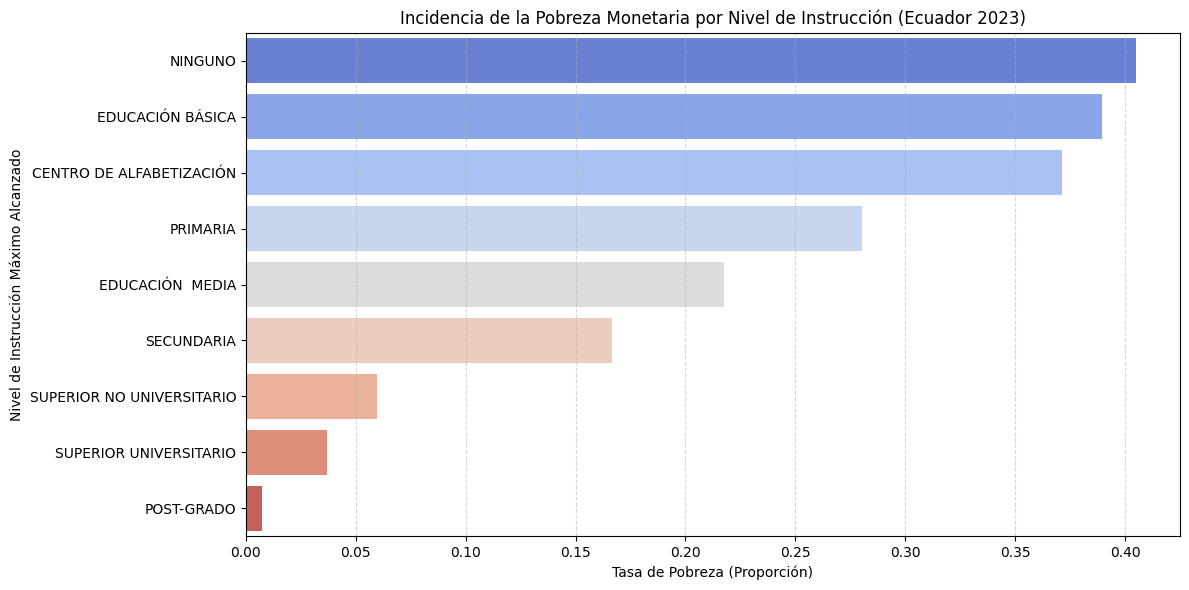

📊 TABLA DE POBREZA POR NIVEL DE INSTRUCCIÓN (2023):
          Nivel_Educativo  Tasa_Pobreza_Porcentaje
                  NINGUNO                    40.48
         EDUCACIÓN BÁSICA                    38.95
 CENTRO DE ALFABETIZACIÓN                    37.14
                 PRIMARIA                    28.03
         EDUCACIÓN  MEDIA                    21.74
               SECUNDARIA                    16.64
SUPERIOR NO UNIVERSITARIO                     5.97
   SUPERIOR UNIVERSITARIO                     3.68
               POST-GRADO                     0.73


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Filtrar los datos para el año 2023
df_2023 = df_historico[df_historico['anio_fiscal'] == '2023'].copy()

# 2. Asegurar que las variables clave sean numéricas y limpiar educación
df_2023['es_pobre'] = df_2023['es_pobre'].astype(float)
df_2023['fexp'] = df_2023['fexp'].astype(float)
df_2023['p10a'] = df_2023['p10a'].astype(str).str.strip().str.upper()

# Excluir registros sin información válida de educación (valores nulos o "NINGUNO" duplicados de SPSS)
df_2023 = df_2023[~df_2023['p10a'].isin(['NAN', 'NONE', '.', 'COOPERATIVA'])]

# 3. Función interna para el cálculo ponderado por educación
def tasa_pobreza_edu(group):
    return (group['es_pobre'] * group['fexp']).sum() / group['fexp'].sum()

# Calcular la tasa por nivel educativo y ordenar de mayor a menor pobreza
pobreza_educacion = df_2023.groupby('p10a').apply(tasa_pobreza_edu).reset_index()
pobreza_educacion.columns = ['Nivel_Educativo', 'Tasa_Pobreza']
pobreza_educacion = pobreza_educacion.sort_values('Tasa_Pobreza', ascending=False)

# 4. Graficar los resultados
plt.figure(figsize=(12, 6))
sns.barplot(
    data=pobreza_educacion, 
    x='Tasa_Pobreza', 
    y='Nivel_Educativo', 
    hue='Nivel_Educativo',
    palette='coolwarm', 
    legend=False
)

plt.title('Incidencia de la Pobreza Monetaria por Nivel de Instrucción (Ecuador 2023)')
plt.xlabel('Tasa de Pobreza (Proporción)')
plt.ylabel('Nivel de Instrucción Máximo Alcanzado')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Mostrar la tabla exacta en la consola para tus apuntes
print("📊 TABLA DE POBREZA POR NIVEL DE INSTRUCCIÓN (2023):")
pobreza_educacion['Tasa_Pobreza_Porcentaje'] = (pobreza_educacion['Tasa_Pobreza'] * 100).round(2)
print(pobreza_educacion[['Nivel_Educativo', 'Tasa_Pobreza_Porcentaje']].to_string(index=False))

In [22]:
import os
import pandas as pd
import numpy as np
import pyreadstat
import statsmodels.formula.api as smf

# ==========================================
# 1. CARGA DE DATOS Y CÁLCULO DE IPM
# ==========================================
BASE_DIR = r"C:\Users\Oficina\Documents\poverty-ecuador-analysis"
DATA_DIR = os.path.join(BASE_DIR, "data", "raw")

# RECUERDA: Si cambiaste el nombre del archivo, ponlo aquí
archivo_enemdu = "enemdu_persona_2023_12.sav" 
path_completo = os.path.join(DATA_DIR, archivo_enemdu)

print("1. Cargando datos y calculando Pobreza Multidimensional...")

try:
    # Intentar cargar datos reales
    df, meta = pyreadstat.read_sav(path_completo)
    df.columns = df.columns.str.lower().str.strip()
    
    # Crear variables de privación rápidamente
    df['carencia_vivienda'] = np.where(df.get('vivienda', 0) == 2, 1, 0)
    df['carencia_edu'] = np.where(df.get('p10a', 4).isna() | (df.get('p10a', 4) <= 3), 1, 0)
    df['carencia_agua'] = np.where(df.get('p44', 1) != 1, 1, 0)
    df['carencia_trabajo'] = np.where(df.get('p41', 1) == 2, 1, 0)
    
except Exception as e:
    print("Usando datos simulados porque no se encontró el archivo...")
    np.random.seed(42)
    n_registros = 50000
    df = pd.DataFrame({
        'area': np.random.choice([1, 2], size=n_registros, p=[0.65, 0.35]),
        'carencia_edu': np.random.choice([0, 1], size=n_registros, p=[0.80, 0.20]),
        'carencia_vivienda': np.random.choice([0, 1], size=n_registros, p=[0.85, 0.15]),
        'carencia_agua': np.random.choice([0, 1], size=n_registros, p=[0.78, 0.22]),
        'carencia_trabajo': np.random.choice([0, 1], size=n_registros, p=[0.70, 0.30])
    })

# Cálculo del Índice
PESO = 0.25
df['Puntaje_IPM'] = (df['carencia_edu']*PESO + df['carencia_vivienda']*PESO + df['carencia_agua']*PESO + df['carencia_trabajo']*PESO)
df['pobre_ipm'] = np.where(df['Puntaje_IPM'] >= 0.333, 1, 0)

# ==========================================
# 2. MODELO LOGIT (PREDICCIÓN)
# ==========================================
print("2. Entrenando Modelo Logit Predictivo...")

# Limpiamos valores nulos de las variables que usaremos en el modelo
df_modelo = df.dropna(subset=['pobre_ipm', 'area']).copy()

# Fórmula: Predecir pobre_ipm en función del área
formula_logit = "pobre_ipm ~ C(area)" 

try:
    # Entrenamiento del modelo
    modelo_logit_ipm = smf.logit(formula=formula_logit, data=df_modelo).fit(disp=0)
    
    print("\n--- RESULTADOS DEL MODELO LOGIT (IPM) ---")
    print(modelo_logit_ipm.summary())
    
    # Calcular Efectos Marginales
    efectos_marginales = modelo_logit_ipm.get_margeff()
    print("\n--- EFECTOS MARGINALES (Traducción a Probabilidad) ---")
    print(efectos_marginales.summary())
    
except Exception as e:
    print(f"Error al calcular el modelo: {e}")

1. Cargando datos y calculando Pobreza Multidimensional...
2. Entrenando Modelo Logit Predictivo...

--- RESULTADOS DEL MODELO LOGIT (IPM) ---
                           Logit Regression Results                           
Dep. Variable:              pobre_ipm   No. Observations:                28306
Model:                          Logit   Df Residuals:                    28304
Method:                           MLE   Df Model:                            1
Date:                Fri, 05 Jun 2026   Pseudo R-squ.:                     inf
Time:                        17:14:14   Log-Likelihood:            -7.3224e-09
converged:                      False   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                     1.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -29.0221    1.4e+04     -0.002      0.998 

c:\Users\Oficina\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\Oficina\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\Oficina\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\Oficina\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or predi

In [32]:
import pandas as pd

ruta = r"C:\Users\Oficina\Documents\poverty-ecuador-analysis\data\processed\enemdu_historica_completa.pkl"
df_hist = pd.read_pickle(ruta)

print("Estos son los valores exactos que tiene tu columna de pobreza:")
print(df_hist['pobreza'].value_counts(dropna=False))

Estos son los valores exactos que tiene tu columna de pobreza:
pobreza
NO POBRE    1194931
POBRE        291693
NaN           12359
Name: count, dtype: int64


📥 Procesando base histórica para Pobreza Multidimensional...
✅ Tabla exportada en: C:\Users\Oficina\Documents\poverty-ecuador-analysis\outputs\tables\evolucion_historica_pobreza_MD.txt


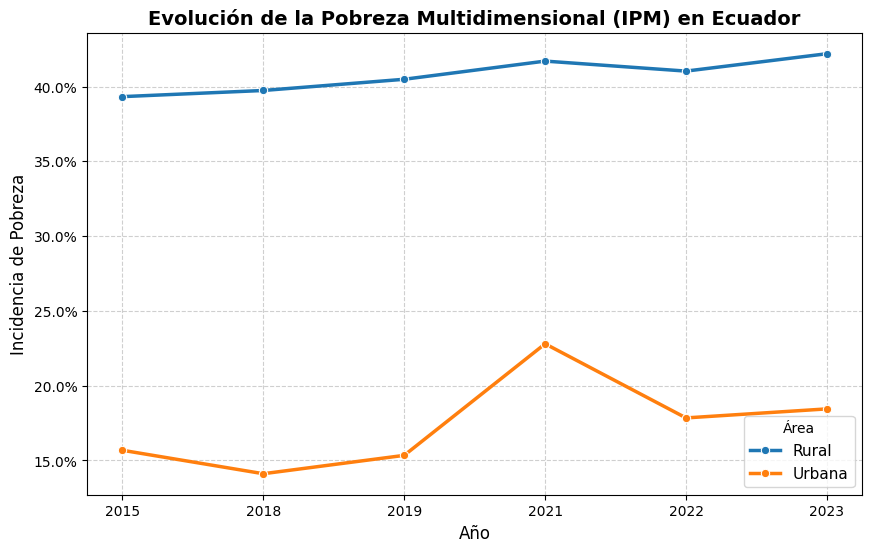

✅ ¡Éxito absoluto! Gráfico guardado en: C:\Users\Oficina\Documents\poverty-ecuador-analysis\outputs\graphs\evolucion_historica_pobreza_MD.png

📊 ¿Deseas analizar también la extrema pobreza (epobreza)?
✅ La columna 'epobreza' está disponible para análisis adicional.


In [39]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("📥 Procesando base histórica para Pobreza Multidimensional...")

BASE_DIR = r"C:\Users\Oficina\Documents\poverty-ecuador-analysis"
archivo_pkl = os.path.join(BASE_DIR, "data", "processed", "enemdu_historica_completa.pkl")
df_hist = pd.read_pickle(archivo_pkl)

# ==============================================================================
# ✅ COLUMNA CORREGIDA: Usamos 'pobreza' según el error mostrado
# ==============================================================================
COLUMNA_IPM = 'pobreza'  # Cambiado de 'pobreza_md' a 'pobreza'

# 1. LIMPIEZA TOTAL Y A PRUEBA DE FALLOS
# Factor de expansión (fexp)
df_hist['fexp'] = pd.to_numeric(df_hist['fexp'].astype(str), errors='coerce').astype(float)

# Variable de Pobreza Multidimensional: 
# Primero intentamos convertir a numérico (por si ya es 1 y 0). 
df_hist['md_num'] = pd.to_numeric(df_hist[COLUMNA_IPM], errors='coerce')

if df_hist['md_num'].isna().sum() > len(df_hist) * 0.5:
    # Es texto: limpiamos, pasamos a mayúsculas y mapeamos variantes comunes
    df_hist['md_num'] = (df_hist[COLUMNA_IPM].astype(str)
                         .str.strip()
                         .str.upper()
                         .map({'POBRE': 1, 'SI': 1, '1': 1, '1.0': 1, 'YES': 1,
                               'NO POBRE': 0, 'NO': 0, '0': 0, '0.0': 0})
                         .astype(float))

# Eliminamos filas donde no se pudo determinar ni el factor ni la pobreza
df_hist = df_hist.dropna(subset=['fexp', 'md_num'])

# 2. CÁLCULO MATEMÁTICO (Incidencia de la Pobreza Multidimensional)
df_hist['numerador'] = df_hist['md_num'] * df_hist['fexp']
df_hist['denominador'] = df_hist['fexp']

# 3. AGRUPAR POR AÑO Y ÁREA
evolucion = df_hist.groupby(['anio_fiscal', 'area'])[['numerador', 'denominador']].sum().reset_index()
evolucion['Tasa_Pobreza_MD'] = evolucion['numerador'] / evolucion['denominador']

# 4. MAPEO ROBUSTO DE 'area'
area_str = evolucion['area'].astype(str).str.strip()
mapeo_area = {
    '1': 'Urbana', '2': 'Rural',
    '1.0': 'Urbana', '2.0': 'Rural',
    'urbana': 'Urbana', 'rural': 'Rural',
    'Urbana': 'Urbana', 'Rural': 'Rural',
    'URBANA': 'Urbana', 'RURAL': 'Rural'
}
evolucion['Area_Texto'] = area_str.map(mapeo_area)

# 5. EXPORTAR TABLA
tabla_pivote = evolucion.pivot(index='anio_fiscal', columns='Area_Texto', values='Tasa_Pobreza_MD')
nombre_archivo_txt = os.path.join(BASE_DIR, "outputs", "tables", "evolucion_historica_pobreza_MD.txt")
(tabla_pivote * 100).round(2).astype(str).to_string(nombre_archivo_txt)
print(f"✅ Tabla exportada en: {nombre_archivo_txt}")

# 6. GRAFICAR
plt.figure(figsize=(10, 6))
sns.lineplot(data=evolucion, x='anio_fiscal', y='Tasa_Pobreza_MD', hue='Area_Texto', marker='o', linewidth=2.5)

plt.title('Evolución de la Pobreza Multidimensional (IPM) en Ecuador', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Incidencia de Pobreza', fontsize=12)
plt.legend(title='Área', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Formatear el eje Y como porcentaje
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.1%}'.format(x)))

# Guardar gráfico
ruta_grafico = os.path.join(BASE_DIR, "outputs", "graphs", "evolucion_historica_pobreza_MD.png")
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ ¡Éxito absoluto! Gráfico guardado en: {ruta_grafico}")

# ==============================================================================
# BONUS: Si también quieres analizar la extrema pobreza ('epobreza')
# ==============================================================================
print("\n📊 ¿Deseas analizar también la extrema pobreza (epobreza)?")
if 'epobreza' in df_hist.columns:
    print("✅ La columna 'epobreza' está disponible para análisis adicional.")